In [1]:
import sys
sys.path.append('../')

In [2]:
from importlib import reload
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Winkler/Warder titration
- titration of mixed NaOH + Na2CO3 solution by HCl
- w/ or w/o BaCl2 addition
- considers activity coefficient (Davies model)

# Load Data

In [3]:
import eq_solver
from pprint import pprint

In [4]:
temp_deg = 25.0
s = eq_solver.System.from_yaml('Na-Ba-CO3.yaml')

# ----------------------------------------------------------------------------------------
# 100 mL of
#  - 0.08 mol/L NaOH
#  - 0.01 mol/L Na2CO3
#  - some BaCl2,
#  titrated by 1 mol/L HCl
# ----------------------------------------------------------------------------------------

v = 0.1
n_naoh = 0.08 * v
n_na2co3 = 0.01 * v
c_bacl2_list = [0.0, 0.005, 0.01, 0.1, 0.5, 1.0]
v_hcl_list = np.linspace(0.0, (n_naoh + n_na2co3) * 1.2, 100)
cond_list = []
for c_bacl2 in c_bacl2_list:
    n_bacl2 = c_bacl2 * v
    for v_hcl in v_hcl_list:
        v_total = v + v_hcl
        d = {
            'carbonate': n_na2co3 / v_total, 
            'barium': n_bacl2 / v_total, 
            'sodium': (n_naoh + 2*n_na2co3) / v_total, 
            'chloride': (v_hcl * 1.0 + 2 * n_bacl2) / v_total
        }
        cond_list.append(eq_solver.Conditions.from_dict(s, d))
print('------ function arguments & return values ------')
pprint(s.specs)


------ function arguments & return values ------
SystemSpecs(n_vars=5,
            n_loga=3,
            n_solid=1,
            n_ionic_strength=1,
            arguments=('Log a(H+)',
                       'Log a(CO3^2-)',
                       'Log a(Ba2+)',
                       'Amount of solid BaCO3(s)',
                       'Ionic strength'),
            returns=('Conservation of component "carbonate"',
                     'Conservation of component "barium"',
                     'Solid-liquid equilibrium for BaCO3(s)',
                     'Charge neutrality',
                     'Self-consistency of Ionic strength'))


# Calculation

In [5]:
results = eq_solver.solve_for_conditions(s, cond_list)

In [7]:
df = eq_solver.get_total_aq(results)
df_C = eq_solver.get_distribution(results, 'carbonate', relative=True)

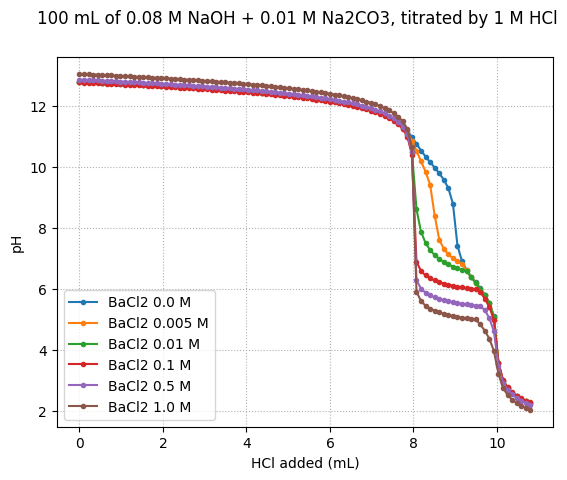

In [8]:
plt.figure()
plt.suptitle('100 mL of 0.08 M NaOH + 0.01 M Na2CO3, titrated by 1 M HCl')
for i, c_bacl2 in enumerate(c_bacl2_list):
    n = len(v_hcl_list)
    sub_df = df.iloc[i*n:(i+1)*n, :]
    plt.plot(v_hcl_list*1000, sub_df['pH'], '.-', label=f'BaCl2 {c_bacl2} M')
plt.ylabel('pH')
plt.xlabel('HCl added (mL)')
plt.legend()
plt.grid(True, ls=':')
plt.show()

Text(0, 0.5, 'Distribution (%)')

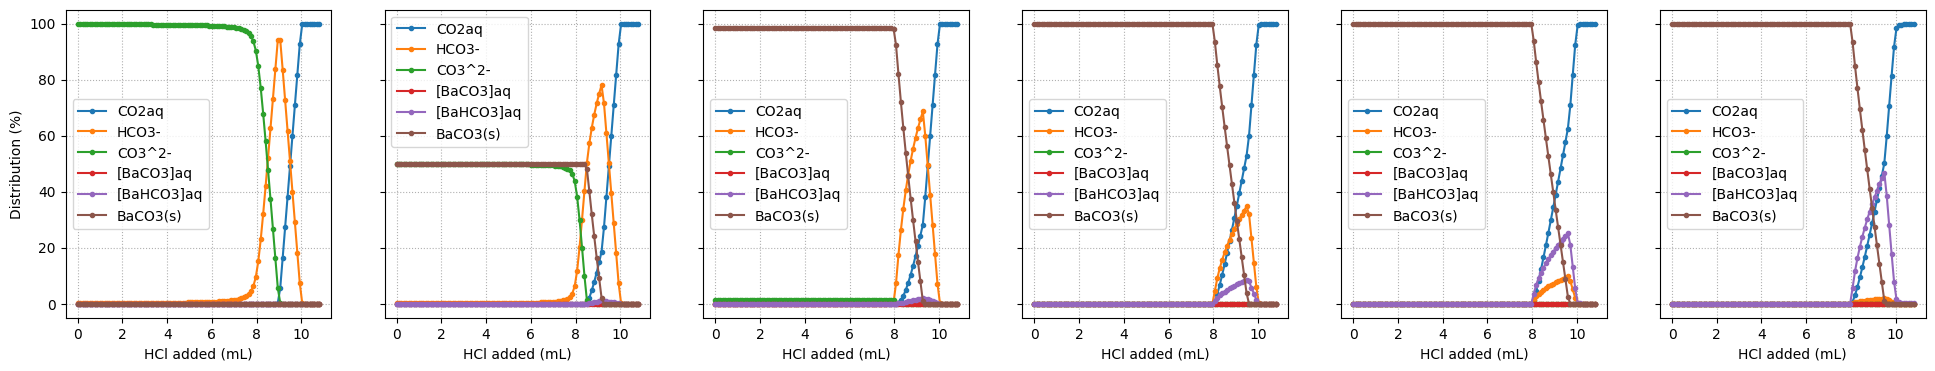

In [9]:
ncols = len(c_bacl2_list)

fig, axes = plt.subplots(ncols=ncols, sharex=True, sharey=True)
fig.set_size_inches(ncols*4, 4)

for i in range(ncols):
    cols = [c for c in df_C.columns if 'C' in c and 'cond.' not in c]
    n = len(v_hcl_list)
    sub_df = df_C.iloc[i*n:(i+1)*n,:]
    axes[i].plot(v_hcl_list*1000, sub_df[cols], '.-', label=sub_df[cols].columns)
for ax in axes:
    ax.legend()
    ax.set_xlabel('HCl added (mL)')
    ax.grid(True, ls=':')
axes[0].set_ylabel('Distribution (%)')


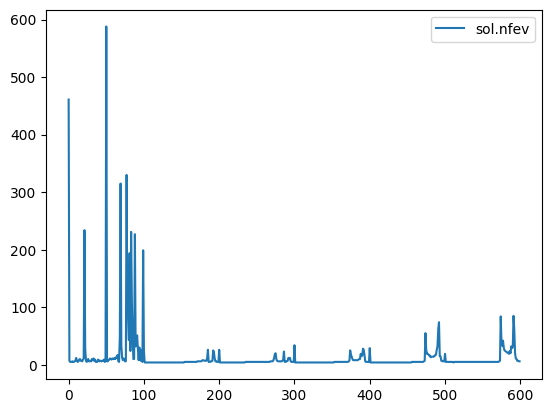

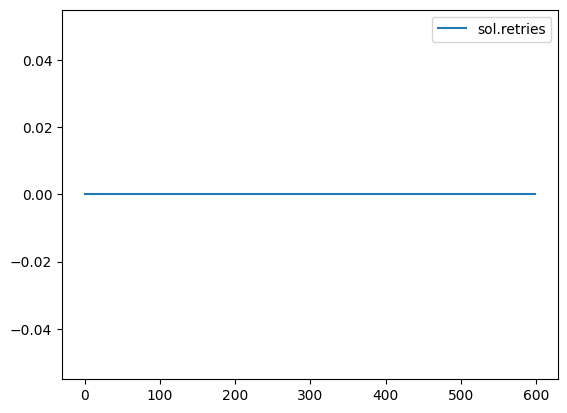

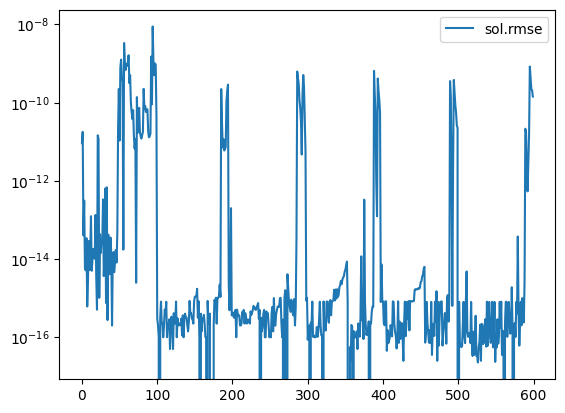

In [10]:
# convergence w/o Ba is unstable, but rmse is small enough.
df.plot(y='sol.nfev')
df.plot(y='sol.retries')
df.plot(y='sol.rmse')
plt.yscale('log')